<a href="https://colab.research.google.com/github/arjunraj13/pix2pix-image-translation/blob/main/GAN_Image_Translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch torchvision matplotlib pillow
!pip install kaggle

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from PIL import Image

In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 14.61 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [ ]:
%cd pytorch-CycleGAN-and-pix2pix
!bash datasets/download_pix2pix_dataset.sh facades

/content/pytorch-CycleGAN-and-pix2pix
Specified [facades]
for details.

--2026-02-25 18:41:57--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘./datasets/facades.tar.gz’

./datasets/facades. 100%[===================>]  28.77M  6.06MB/s    in 5.6s    

2026-02-25 18:42:03 (5.10 MB/s) - ‘./datasets/facades.tar.gz’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.

In [ ]:
!bash datasets/download_pix2pix_dataset.sh maps

Specified [maps]
for details.

--2026-02-25 18:42:03--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 250242400 (239M) [application/x-gzip]
Saving to: ‘./datasets/maps.tar.gz’

./datasets/maps.tar 100%[===================>] 238.65M  4.36MB/s    in 57s     

2026-02-25 18:43:00 (4.21 MB/s) - ‘./datasets/maps.tar.gz’ saved [250242400/250242400]

maps/
maps/train/
maps/train/1.jpg
maps/train/10.jpg
maps/train/100.jpg
maps/train/1000.jpg
maps/train/1001.jpg
maps/train/1002.jpg
maps/train/1003.jpg
maps/train/1004.jpg
maps/train/1005.jpg
maps/train/1006.jpg
maps/train/1007.jpg
maps/train/1008.jpg
maps/train/1009.jpg
maps/train/101.jpg
maps/train/1010.jpg
maps/train/1011.jpg
maps/train/1012.jpg
maps/train/1013.jpg
maps/train/1014.jpg

In [ ]:
class FacadesDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.files = [os.path.join(root, f) for f in os.listdir(root)]

        self.transform = transforms.Compose([
            transforms.Resize((256,512)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,)*3,(0.5,)*3)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        img = self.transform(img)

        input_img = img[:, :, :256]
        target_img = img[:, :, 256:]

        return input_img, target_img

In [ ]:
train_ds = FacadesDataset("./datasets/facades/train")
loader = DataLoader(train_ds, batch_size=4, shuffle=True)

In [ ]:
class Down(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers=[nn.Conv2d(in_c,out_c,4,2,1,bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        self.model=nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x)

class Up(nn.Module):
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers=[
            nn.ConvTranspose2d(in_c,out_c,4,2,1,bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.model=nn.Sequential(*layers)

    def forward(self,x,skip):
        x=self.model(x)
        return torch.cat([x,skip],1)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1=Down(3,64,normalize=False)
        self.d2=Down(64,128)
        self.d3=Down(128,256)
        self.d4=Down(256,512)

        self.u1=Up(512,256)
        self.u2=Up(512,128)
        self.u3=Up(256,64)

        self.final=nn.ConvTranspose2d(128,3,4,2,1)

    def forward(self,x):
        d1=self.d1(x)
        d2=self.d2(d1)
        d3=self.d3(d2)
        d4=self.d4(d3)

        u1=self.u1(d4,d3)
        u2=self.u2(u1,d2)
        u3=self.u3(u2,d1)

        return torch.tanh(self.final(u3))

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,x,y):
        return self.model(torch.cat([x,y],dim=1))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(),lr=2e-4,betas=(0.5,0.999))
opt_D = torch.optim.Adam(D.parameters(),lr=2e-4,betas=(0.5,0.999))

bce = nn.BCELoss()
l1 = nn.L1Loss()

In [ ]:
epochs = 50

for epoch in range(epochs):
    for x,y in loader:
        x,y = x.to(device), y.to(device)

        # Train D
        fake = G(x)

        real_pred = D(x,y)
        fake_pred = D(x,fake.detach())

        loss_D = bce(real_pred, torch.ones_like(real_pred)) + \
                 bce(fake_pred, torch.zeros_like(fake_pred))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train G
        fake_pred = D(x,fake)
        loss_G = bce(fake_pred, torch.ones_like(fake_pred)) + 50*l1(fake,y)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(epoch, loss_D.item(), loss_G.item())

0 0.7937685251235962 37.647071838378906
1 0.7554370164871216 38.934513092041016
2 0.8100292682647705 46.183013916015625
3 0.6952385902404785 40.744842529296875
4 0.7600359916687012 40.97455596923828
5 0.5291570425033569 39.66815185546875
6 0.7343077659606934 38.49418258666992
7 0.7960498929023743 32.29153060913086
8 0.7926698923110962 30.539974212646484
9 0.6253851056098938 31.14201545715332
10 0.8283390402793884 31.216150283813477
11 0.7069922685623169 35.287925720214844
12 0.630398690700531 35.942325592041016
13 0.8587096929550171 29.376605987548828
14 1.2030667066574097 25.68032455444336
15 0.7571649551391602 31.14414405822754
16 0.6138732433319092 33.10508346557617
17 0.5623995661735535 29.77923583984375
18 1.085526704788208 24.553993225097656
19 1.1136873960494995 27.212020874023438
20 1.4950461387634277 25.828516006469727
21 0.8528221249580383 30.87972068786621
22 1.4215786457061768 20.11456298828125
23 0.425987184047699 32.69505310058594
24 0.7543057203292847 31.546167373657227


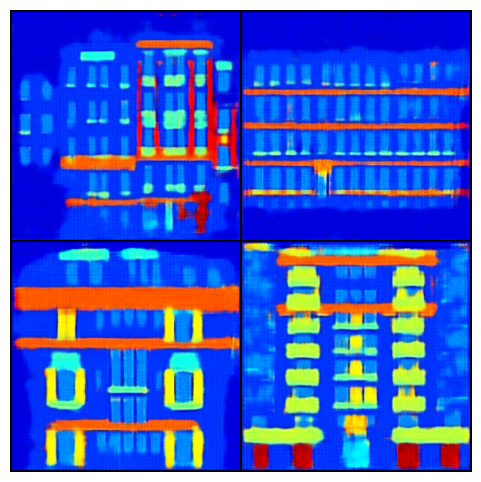

In [ ]:
x,y = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    fake = G(x).cpu()

def show(img):
    img = (img + 1) / 2   # IMPORTANT denormalize
    grid = torchvision.utils.make_grid(img, nrow=2)
    plt.figure(figsize=(6,6))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")

show(fake)

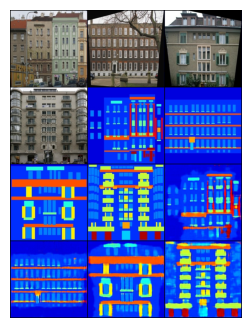

In [ ]:
def show_triplet(a,b,c):
    a=(a+1)/2; b=(b+1)/2; c=(c+1)/2
    grid=torchvision.utils.make_grid(torch.cat([a,b,c],0),nrow=3)
    plt.figure(figsize=(10,4))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")

show_triplet(x.cpu(), y, fake)

In [ ]:
torch.save(G.state_dict(),"G_50.pth")